In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from plot.plot_progress import gather_metrics
from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
import pandas as pd
import matplotlib.ticker as ticker

In [2]:
workspace_base_path = lambda item: os.path.join('old_workspaces', 'nanogpt_speedrun', item)

In [3]:
ori_results = find_levels_in_configs_glob(
    [
        'old_workspaces/nanogpt_speedrun/record_*_20250401_*',
        'old_workspaces/nanogpt_speedrun/record_*_20250331_*'
    ]
)

Found 279 directories


In [4]:
results = {
    k: v 
    for k, v in ori_results.items() 
        # if v['levels'][0] == 1 and v['ideator'] == 'dummy'
        if v['levels'][0] == 0 and len(v['levels']) == 1 and v['ideator'] == 'dummy'
        # if v['levels'][0] == 1 and len(v['levels']) == 1 and v['ideator'] == 'dummy'
        # if v['levels'][0] == 2 and len(v['levels']) and v['ideator'] == 'dummy'
}

In [5]:
len(results)

37

In [6]:
def track_data(record, level, new_results_dict):
    # Initialize lists to store the cumulative min train time and the corresponding val loss
    cum_min_train_time = []
    corresponding_val_loss = []
    
    # Initialize the current min train time and the corresponding val loss
    current_min_train_time = float('inf')
    current_corresponding_val_loss = None
    
    # Iterate over the rows in the dataframe
    for index, row in new_results_dict[f'record_{record}_{level}'][1]['metrics'].iterrows():
        # If the current train time is smaller than the current min train time, update the current min train time and the corresponding val loss
        if row['train_time'] < current_min_train_time:
            current_min_train_time = row['train_time']
            current_corresponding_val_loss = row['val_loss']
    
        if np.isnan(row['train_time']) and np.isnan(row['val_loss']):
            continue
        if row['val_loss'] > 5:
            continue
        # Append the current min train time and the corresponding val loss to the lists
        cum_min_train_time.append(current_min_train_time)
        corresponding_val_loss.append(current_corresponding_val_loss)
    
    # Convert the lists to pandas Series
    best_train_time_searched = pd.Series(cum_min_train_time)
    best_val_loss_at_min_train_time = pd.Series(corresponding_val_loss)
    return best_train_time_searched, best_val_loss_at_min_train_time

In [7]:
def gather_data_from_results(results):
    for key, value in results.items():
        metrics = gather_metrics(
            workspace_path=workspace_base_path(key),
            metrics=['val_loss', 'train_time'],
            workspace_template_path=os.path.join(
                'workspace_templates', 
                'nanogpt_speedrun', 
                f"record_{value['record']}"
            )
        )
        results[key]['metrics'] = metrics
    # get uniq record and levels
    uniq_records = list(set([item['record'] for item in results.values()]))
    uniq_levels = list(set([item['levels'][0] for item in results.values()]))
    # get the dict with record and level as key
    # {record}_{level} : {metrics}
    
    new_results_keys = [
        f'record_{record}_{level}' 
        for record in [4, 5, 6, 7, 8, 9, 10, 11] 
            for level in uniq_levels
    ]
    # only get the first one from all results
    new_results_dict = {}
    for record in [4, 5, 6, 7, 8, 9, 10, 11]:
        for level in uniq_levels:
            for item in results.items():
                if item[1]['record'] == record and item[1]['levels'][0] == level:
                    if f'record_{record}_{level}' not in new_results_dict \
                    or len(item[1]['metrics']['val_loss']) > \
                    len(new_results_dict[f'record_{record}_{level}'][1]['metrics']['val_loss']):
                        new_results_dict[f'record_{record}_{level}'] = item

    agent_record = {}

    assert len(uniq_levels) == 1
    for record in [4, 5, 6, 7, 8, 9, 10, 11]:
        train_time, val_loss = track_data(record, uniq_levels[0], new_results_dict)
        train_time = train_time[val_loss < 3.32]
        agent_record[record+1] = train_time.min()
    return agent_record, uniq_levels

In [8]:
human_train_time_dict = {
    4: 1301740,
    5: 949528,
    6: 766259,
    7: 773072,
    8: 662205,
    9: 505531,
    10: 477150,
    11: 442985,
    12: 317839
}
    # 4	3.2772	1301740
    # 5	3.2751	949528
    # 6	3.276	766259
    # 7	3.275	773072
    # 8	3.2789	662205
    # 9	3.2785	505531
    # 10	3.2782	477150
    # 11	3.2742	442985


In [9]:
agent_record, uniq_levels = gather_data_from_results(results)

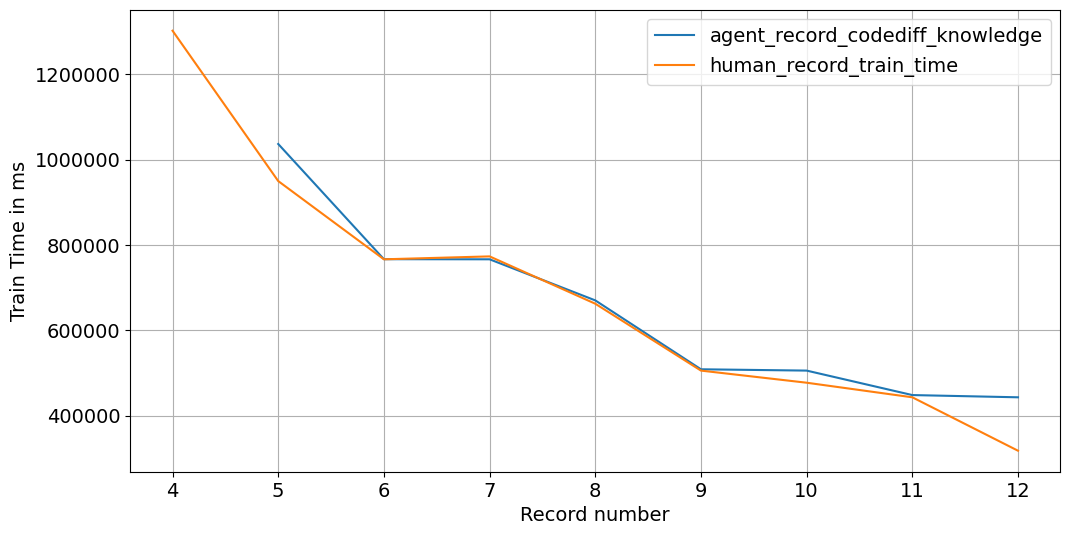

In [10]:
assert len(uniq_levels) == 1
plt.plot(
    agent_record.keys(), 
    agent_record.values(), 
    label='agent_record_codediff_knowledge'
)
plt.plot(
    human_train_time_dict.keys(), 
    human_train_time_dict.values(), 
    label='human_record_train_time'
)
plt.xlabel('Record number')
plt.ylabel('Train Time in ms')
plt.grid()
plt.legend()
def plain_formatter(x, pos):
    return f"{x:.0f}"
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))
plt.show()

In [11]:
uniq_levels

[0]

In [12]:
l1_results = {
    k: v 
    for k, v in ori_results.items() 
        # if v['levels'][0] == 1 and v['ideator'] == 'dummy'
        # if v['levels'][0] == 0 and len(v['levels']) == 1 and v['ideator'] == 'dummy'
        if v['levels'][0] == 1 and len(v['levels']) == 1 and v['ideator'] == 'dummy'
        # if v['levels'][0] == 2 and len(v['levels']) and v['ideator'] == 'dummy'
}

In [13]:
agent_l1_record, uniq_levels = gather_data_from_results(l1_results)

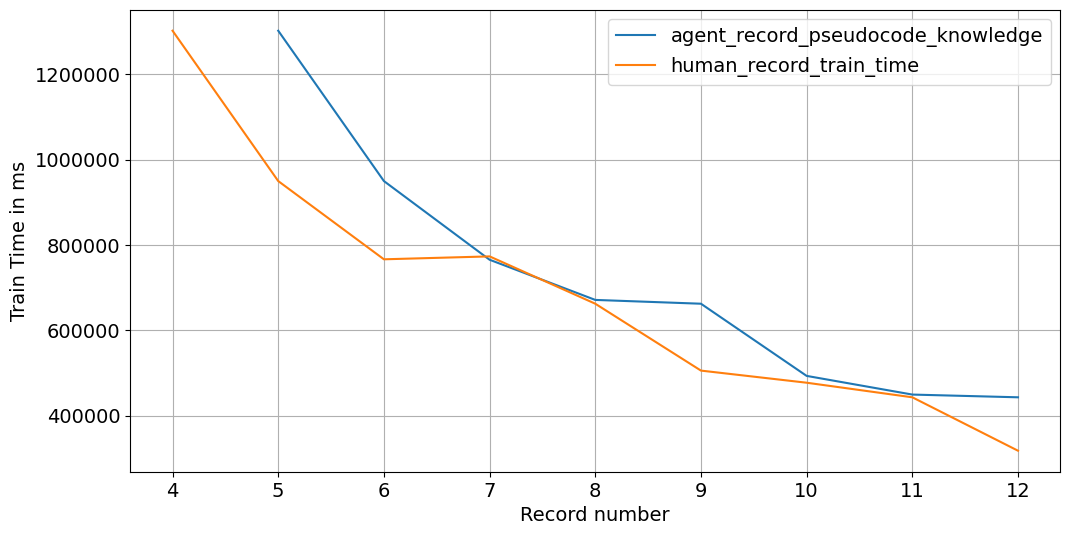

In [14]:
assert len(uniq_levels) == 1
plt.plot(
    agent_l1_record.keys(), 
    agent_l1_record.values(), 
    label='agent_record_pseudocode_knowledge'
)
plt.plot(
    human_train_time_dict.keys(), 
    human_train_time_dict.values(), 
    label='human_record_train_time'
)
plt.xlabel('Record number')
plt.ylabel('Train Time in ms')
plt.grid()
plt.legend()
def plain_formatter(x, pos):
    return f"{x:.0f}"
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))
plt.show()

In [15]:
l2_results = {
    k: v 
    for k, v in ori_results.items() 
        # if v['levels'][0] == 1 and v['ideator'] == 'dummy'
        # if v['levels'][0] == 0 and len(v['levels']) == 1 and v['ideator'] == 'dummy'
        # if v['levels'][0] == 1 and len(v['levels']) == 1 and v['ideator'] == 'dummy'
        if v['levels'][0] == 2 and len(v['levels']) and v['ideator'] == 'dummy'
}

In [16]:
agent_l2_record, uniq_levels = gather_data_from_results(l2_results)

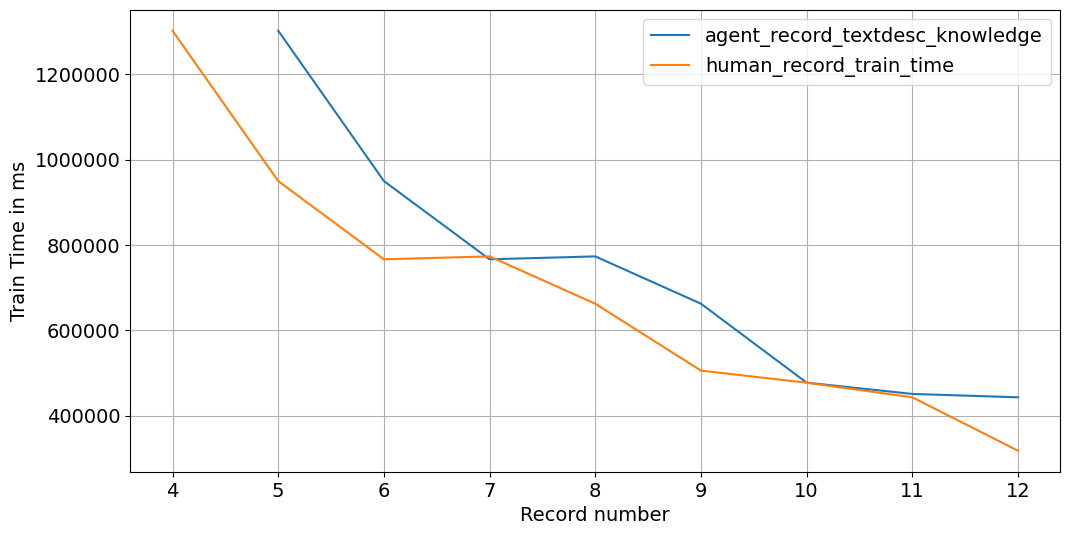

In [17]:
assert len(uniq_levels) == 1
plt.plot(
    agent_l2_record.keys(), 
    agent_l2_record.values(), 
    label='agent_record_textdesc_knowledge'
)
plt.plot(
    human_train_time_dict.keys(), 
    human_train_time_dict.values(), 
    label='human_record_train_time'
)
plt.xlabel('Record number')
plt.ylabel('Train Time in ms')
plt.grid()
plt.legend()
def plain_formatter(x, pos):
    return f"{x:.0f}"
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))
plt.show()

In [25]:
l3_results = {
    k: v 
    for k, v in ori_results.items() 
        # if v['levels'][0] == 1 and v['ideator'] == 'dummy'
        # if v['levels'][0] == 0 and len(v['levels']) == 1 and v['ideator'] == 'dummy'
        # if v['levels'][0] == 1 and len(v['levels']) == 1 and v['ideator'] == 'dummy'
        # if v['levels'][0] == 2 and len(v['levels']) and v['ideator'] == 'dummy'
        if v['levels'][0] == 3 and len(v['levels']) and v['ideator'] == 'dummy'
}

In [26]:
len(l3_results)

8

In [28]:
agent_l3_record, uniq_levels = gather_data_from_results(l3_results)

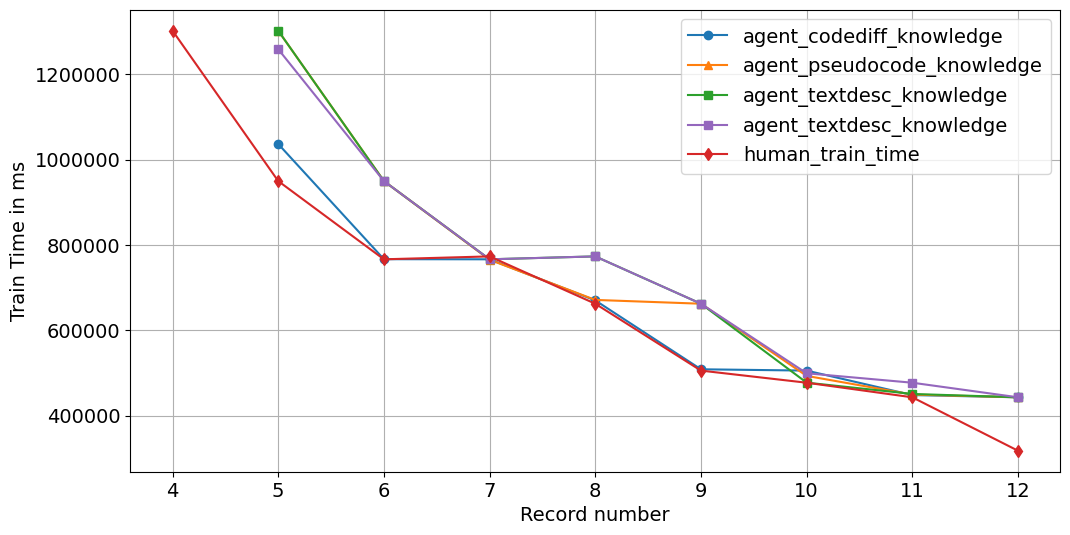

In [29]:
# plt.plot(
#     agent_record.keys(), 
#     agent_record.values(), 
#     label='agent_record_codediff_knowledge'
# )
# plt.plot(
#     agent_l1_record.keys(), 
#     agent_l1_record.values(), 
#     label='agent_record_pseudocode_knowledge'
# )
# plt.plot(
#     agent_l2_record.keys(), 
#     agent_l2_record.values(), 
#     label='agent_record_textdesc_knowledge'
# )
# plt.plot(
#     human_train_time_dict.keys(), 
#     human_train_time_dict.values(), 
#     label='human_record_train_time'
# )
cmap = plt.get_cmap('tab10')
plt.plot(agent_record.keys(), agent_record.values(), 
         label='agent_codediff_knowledge', 
         color=cmap(0), linestyle='-', marker='o')
plt.plot(agent_l1_record.keys(), agent_l1_record.values(), 
         label='agent_pseudocode_knowledge', 
         color=cmap(1), linestyle='-', marker='^')
plt.plot(agent_l2_record.keys(), agent_l2_record.values(), 
         label='agent_textdesc_knowledge', 
         color=cmap(2), linestyle='-', marker='s')
plt.plot(agent_l3_record.keys(), agent_l3_record.values(), 
         label='agent_textdesc_knowledge', 
         color=cmap(4), linestyle='-', marker='s')
plt.plot(human_train_time_dict.keys(), human_train_time_dict.values(), 
         label='human_train_time', 
         color=cmap(3), linestyle='-', marker='d')

plt.xlabel('Record number')
plt.ylabel('Train Time in ms')
plt.grid()
plt.legend()
def plain_formatter(x, pos):
    return f"{x:.0f}"
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))
plt.show()

In [6]:
for key, value in results.items():
    metrics = gather_metrics(
        workspace_path=workspace_base_path(key),
        metrics=['val_loss', 'train_time'],
        workspace_template_path=os.path.join(
            'workspace_templates', 
            'nanogpt_speedrun', 
            f"record_{value['record']}"
        )
    )
    results[key]['metrics'] = metrics


In [7]:
# get uniq record and levels
uniq_records = list(set([item['record'] for item in results.values()]))
uniq_levels = list(set([item['levels'][0] for item in results.values()]))

In [8]:
uniq_records, uniq_levels

([4, 5, 6, 7, 8, 9, 10, 11], [0])

In [9]:
# get the dict with record and level as key
# {record}_{level} : {metrics}

new_results_keys = [
    f'record_{record}_{level}' 
    for record in [4, 5, 6, 7, 8, 9, 10, 11] 
        for level in uniq_levels
]

In [10]:
# only get the first one from all results
new_results_dict = {}
for record in [4, 5, 6, 7, 8, 9, 10, 11]:
    for level in uniq_levels:
        for item in results.items():
            if item[1]['record'] == record and item[1]['levels'][0] == level:
                if f'record_{record}_{level}' not in new_results_dict \
                or len(item[1]['metrics']['val_loss']) > \
                len(new_results_dict[f'record_{record}_{level}'][1]['metrics']['val_loss']):
                    new_results_dict[f'record_{record}_{level}'] = item

In [11]:
new_results_dict.keys()

dict_keys(['record_4_0', 'record_5_0', 'record_6_0', 'record_7_0', 'record_8_0', 'record_9_0', 'record_10_0', 'record_11_0'])

In [14]:
uniq_levels

[0]

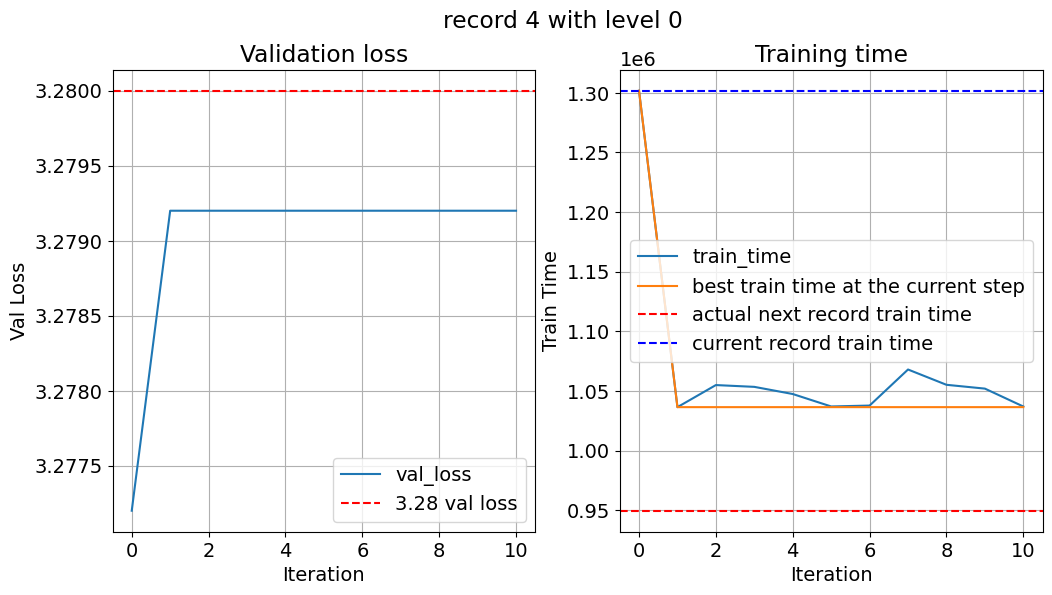

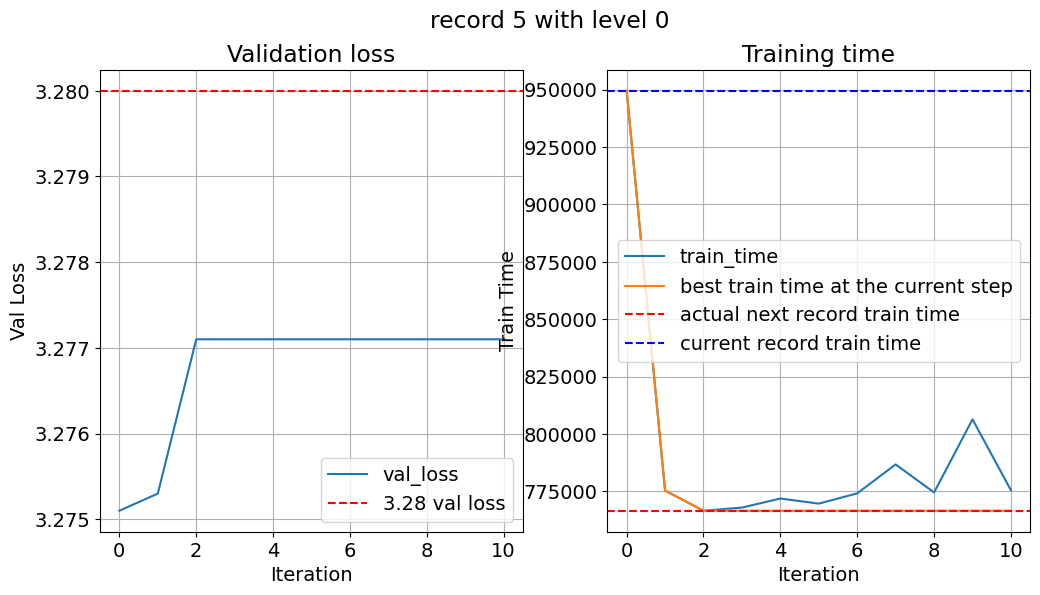

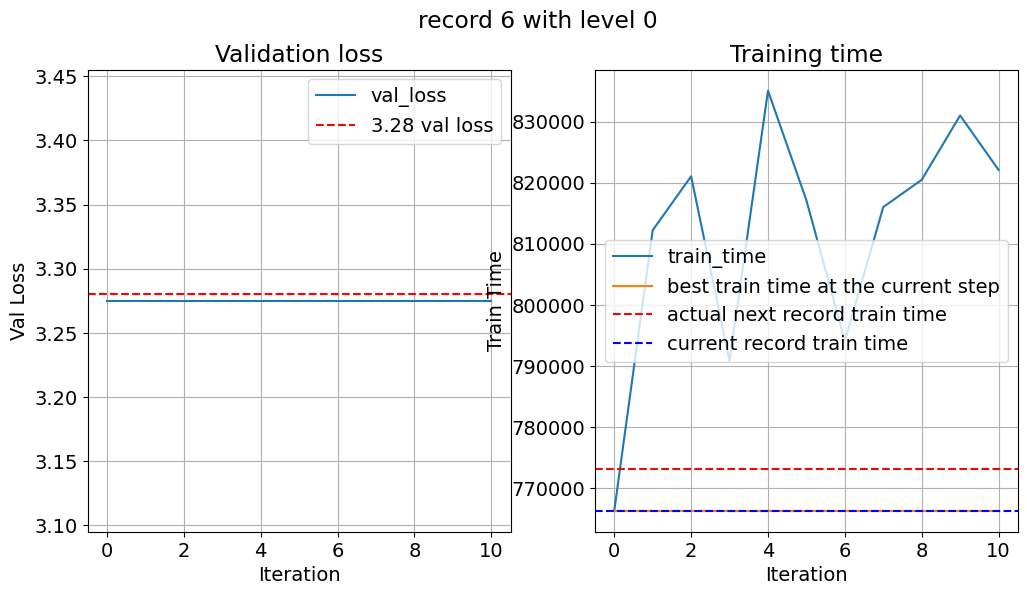

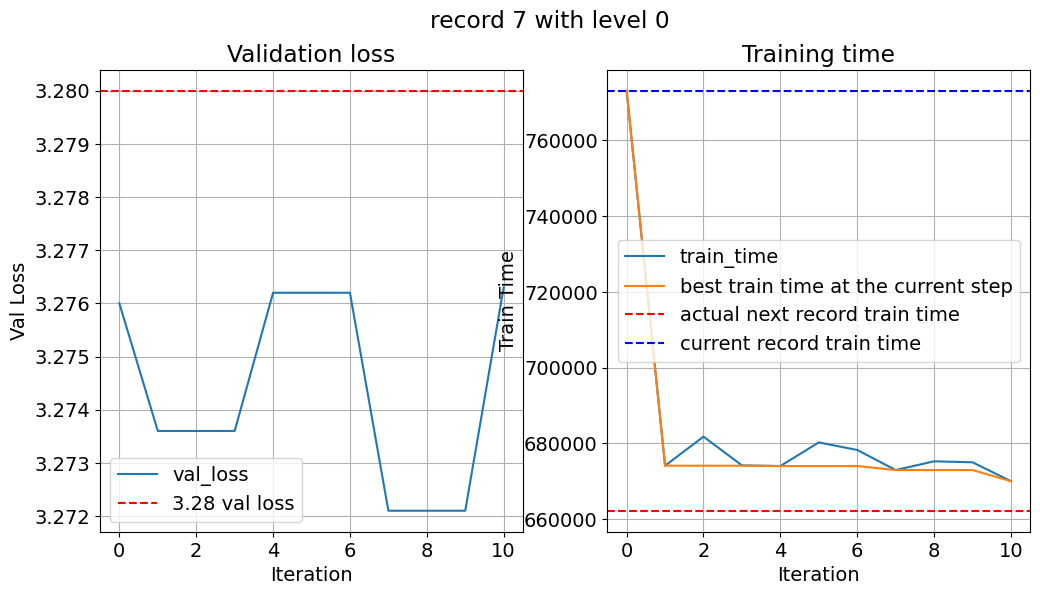

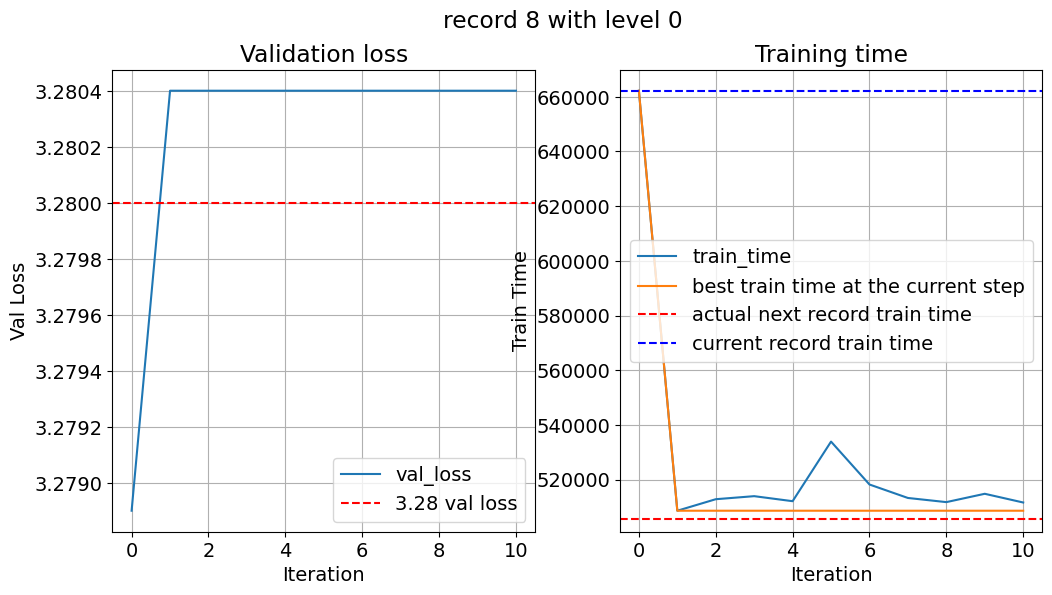

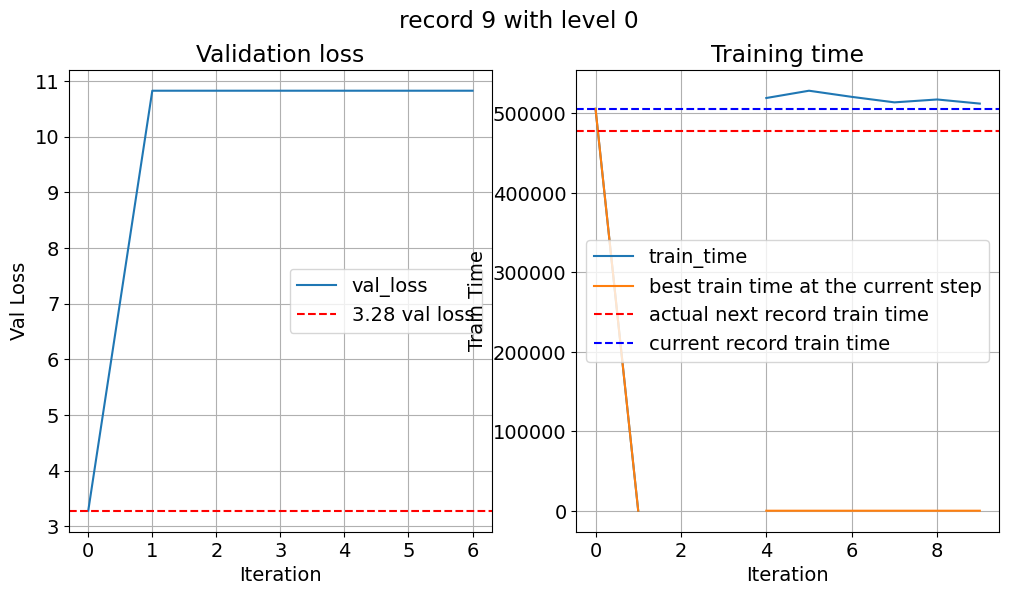

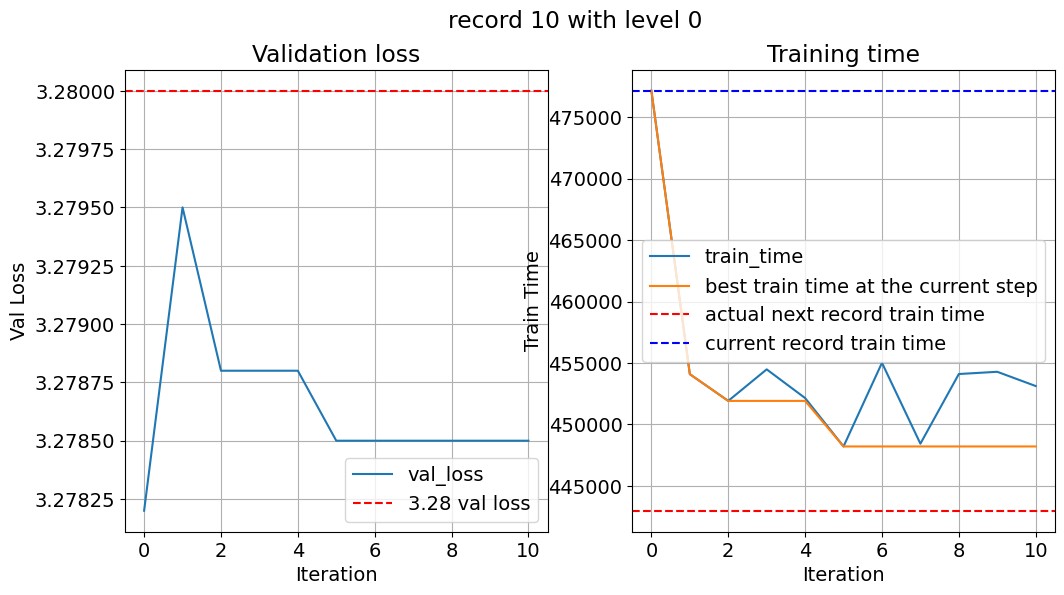

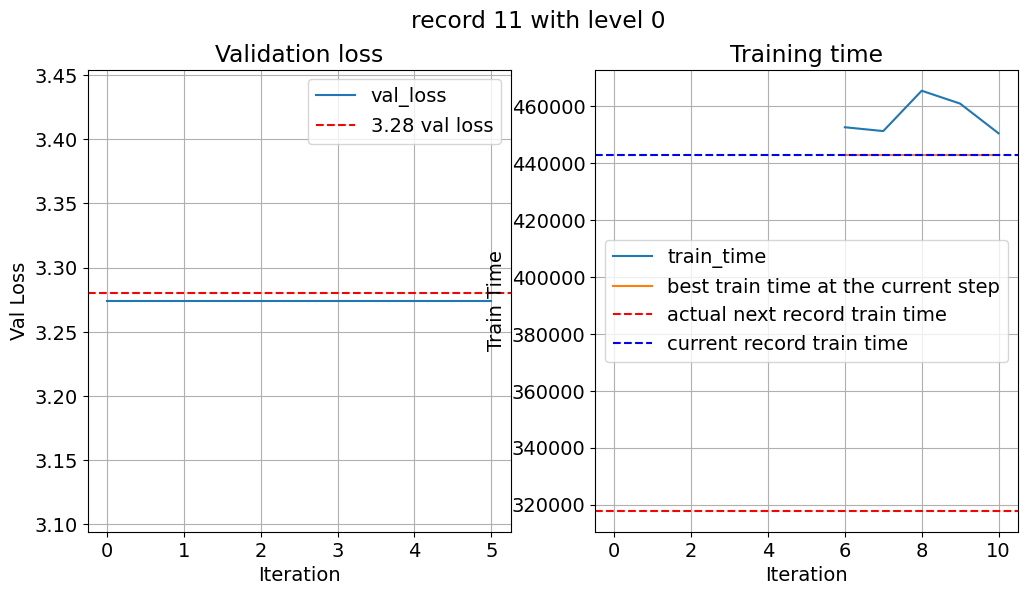

In [15]:
for record in [4, 5, 6, 7, 8, 9, 10, 11]:
# for record in [4, ]:
    for level in uniq_levels:
        fig, ax = plt.subplots(1, 2, figsize=(12, 6))
        train_time, val_loss = track_data(record, level)
        ax[0].plot(val_loss, label='val_loss')
        # add a line of 3.28 val loss
        ax[0].axhline(y=3.28, color='red', linestyle='--', label='3.28 val loss')
        ax[0].set_title('Validation loss')
        ax[0].set_xlabel('Iteration')
        ax[0].set_ylabel('Val Loss')
        ax[0].legend()
        ax[0].grid()

        # ax[1].plot(train_time, label='level 0')
        ax[1].plot(new_results_dict[f'record_{record}_{level}'][1]['metrics']['train_time'], label='train_time')
        # train_time is a series, get the best train time at the current step (best in the first n)
        # get the best train time at the current step
        # similar to cumsum, lets do cummin here
        best_train_time_searched = new_results_dict[f'record_{record}_{level}'][1]['metrics']['train_time'].cummin()
        ax[1].plot(best_train_time_searched, label='best train time at the current step', )
        # add a line of human train time
        ax[1].axhline(y=human_train_time_dict[record+1], color='red', linestyle='--', label='actual next record train time')
        # add current record train time
        ax[1].axhline(y=human_train_time_dict[record], color='blue', linestyle='--', label='current record train time')
        ax[1].set_title('Training time')
        ax[1].set_xlabel('Iteration')
        ax[1].set_ylabel('Train Time')
        ax[1].legend()
        ax[1].grid()
        fig.suptitle(f'record {record} with level {level}')
    #     break
    # break

